# **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# **Load Dataset**

In [ ]:
# menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# memanggil data set lewat gdrive
path = "/content/gdrive/MyDrive/MachineLearning/Praktikum10"

# **Menampilkan Data Awal**

In [ ]:
import pandas as pd
df = pd.read_csv("/content/gdrive/MyDrive/MachineLearning/Praktikum10/Data/weather_classification_data.csv")
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


# **Mengecek Struktur Dataset**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


# **Data Cleaning**

In [ ]:
# Mengecek Nilai Unik Pada Kolom Kategorikal
cat_cols = ['Cloud Cover', 'Season', 'Location', 'Weather Type']
for col in cat_cols:
    print(f"\nNilai unik {col}:")
    print(df[col].unique)


Nilai unik Cloud Cover:
<bound method Series.unique of 0        partly cloudy
1        partly cloudy
2                clear
3                clear
4             overcast
             ...      
13195         overcast
13196           cloudy
13197         overcast
13198         overcast
13199         overcast
Name: Cloud Cover, Length: 13200, dtype: object>

Nilai unik Season:
<bound method Series.unique of 0        Winter
1        Spring
2        Spring
3        Spring
4        Winter
          ...  
13195    Summer
13196    Winter
13197    Autumn
13198    Winter
13199    Autumn
Name: Season, Length: 13200, dtype: object>

Nilai unik Location:
<bound method Series.unique of 0          inland
1          inland
2        mountain
3         coastal
4        mountain
           ...   
13195    mountain
13196     coastal
13197     coastal
13198      inland
13199    mountain
Name: Location, Length: 13200, dtype: object>

Nilai unik Weather Type:
<bound method Series.unique of 0         Rainy
1

In [ ]:
# Mengecek Missing Value
print("\nMissing Value Sebelum Cleaning:")
print(df.isnull().sum())


Missing Value Sebelum Cleaning:
Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64


In [ ]:
# Drop Missing Value
df = df.dropna()

print("\nMissing Value Setelah Cleaning:")
print(df.isnull().sum())


Missing Value Setelah Cleaning:
Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64


In [ ]:
# Encoding Kategori
df_encoded = pd.get_dummies(df, columns=['Cloud Cover', 'Season', 'Location'], drop_first=True)
df_encoded.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Weather Type,Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Season_Spring,Season_Summer,Season_Winter,Location_inland,Location_mountain
0,14.0,73,9.5,82.0,1010.82,2,3.5,Rainy,False,False,True,False,False,True,True,False
1,39.0,96,8.5,71.0,1011.43,7,10.0,Cloudy,False,False,True,True,False,False,True,False
2,30.0,64,7.0,16.0,1018.72,5,5.5,Sunny,False,False,False,True,False,False,False,True
3,38.0,83,1.5,82.0,1026.25,7,1.0,Sunny,False,False,False,True,False,False,False,False
4,27.0,74,17.0,66.0,990.67,1,2.5,Rainy,False,True,False,False,False,True,False,True


In [ ]:
# Memisahkan Target
X = df_encoded.drop(columns=['Weather Type'])
y = df['Weather Type']

In [ ]:
# Split Data Train Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Ukuran Data:")
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Ukuran Data:
Train: (10560, 15)
Test: (2640, 15)


In [ ]:
# Melakukan Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Analisis Korelasi Fitur**

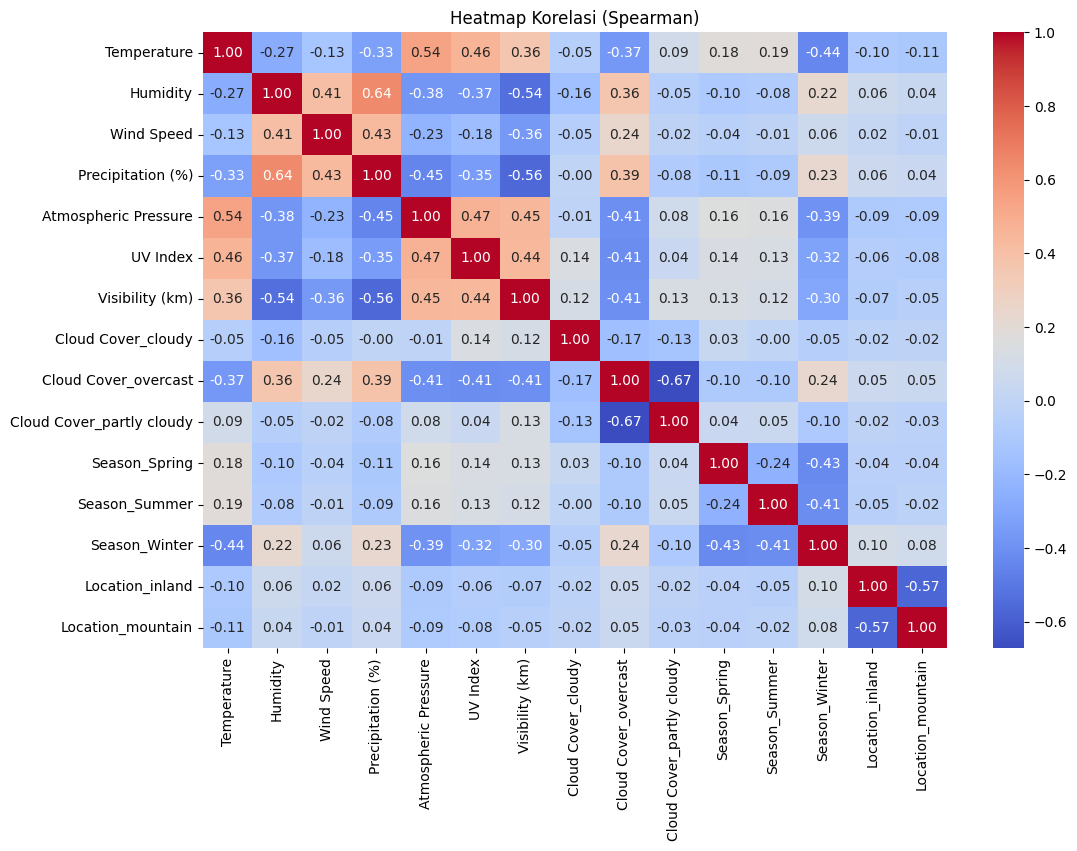

In [ ]:
#Menghitung matriks korelasi menggunakan Spearman
correlation_matrix = df_encoded.drop(columns=['Weather Type']).corr(method='spearman')

#Membuat heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap Korelasi (Spearman)")
plt.show()

# **Visualisasi Distribusi**

/tmp/ipython-input-3325781743.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Weather Type', data=df, palette='Set2')


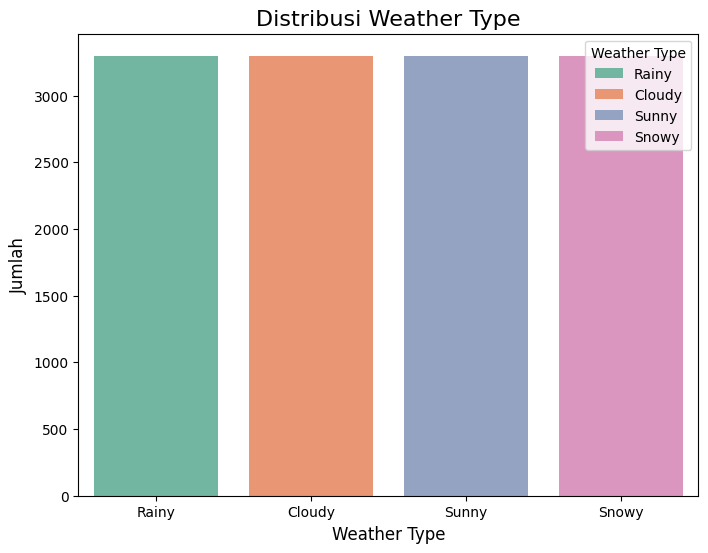

In [ ]:
# Membuat diagram batang untuk status kelulusan
plt.figure(figsize=(8, 6))
sns.countplot(x='Weather Type', data=df, palette='Set2')

# Menambahkan judul dan label
plt.title('Distribusi Weather Type', fontsize=16)
plt.xlabel('Weather Type', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

# Menambahkan legend (adjusted labels for correctness)
plt.legend(title='Weather Type',
           labels=df['Weather Type'].unique(),
           loc='upper right')

# Menampilkan plot
plt.show()

## **Menangani Ketidakseimbangan Kelas Dengan SMOTE**

In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())

from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42, k_neighbors=1) # Set k_neighbors to 1
X_train_smote, y_train_smote = sm.fit_resample(X_train_scaled, y_train)

print("After SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Weather Type
Sunny     2659
Rainy     2653
Cloudy    2649
Snowy     2599
Name: count, dtype: int64
After SMOTE:
Weather Type
Rainy     2659
Sunny     2659
Cloudy    2659
Snowy     2659
Name: count, dtype: int64


# **Menentukan Parameter Terbaik (Hyperparameter Tuning)**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': list(range (1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, n_jobs=-1)
grid.fit(X_train_smote, y_train_smote)

print("Best Params:", grid.best_params_)
print("Best Score (CV):", grid.best_score_)

Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best Score (CV): 0.8980825211830705


# **Melatih Model KNN Terbaik dan Melakukan Prediks**

In [ ]:
best_knn = grid.best_estimator_
best_knn.fit(X_train_smote, y_train_smote)

# Prediksi
y_pred = best_knn.predict(X_test_scaled)

# **Evaluasi Model Dengan Classification Report**

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.83      0.88      0.85       651
       Rainy       0.85      0.89      0.87       647
       Snowy       0.96      0.94      0.95       701
       Sunny       0.95      0.88      0.91       641

    accuracy                           0.90      2640
   macro avg       0.90      0.89      0.90      2640
weighted avg       0.90      0.90      0.90      2640



# **Evaluasi Dengan Confusion Matrix**

In [ ]:
# Melakukan GridSearch
best_model = grid.best_estimator_
print(best_model)

KNeighborsClassifier(metric='euclidean', n_neighbors=3)


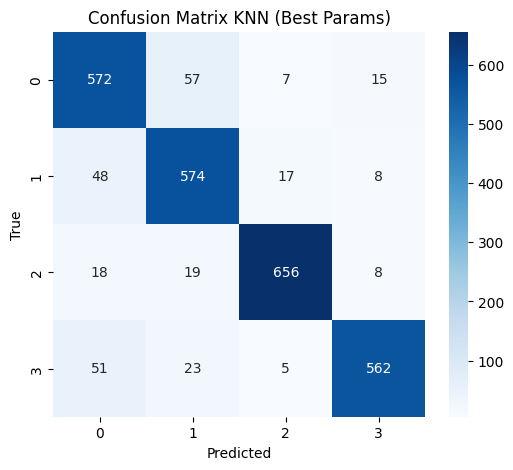

In [ ]:
from sklearn.metrics import confusion_matrix

# Prediksi Menggunakan Model Terbaik
y_pred = best_model.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix KNN (Best Params)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# **Validasi Model Dengan Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_knn, X_train_smote, y_train_smote, cv=5)
print("Cross Validation Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Cross Validation Accuracy: 0.8980825211830705
Std Dev: 0.008410705057267652


# **Menentukan Nilai K opyimal Dengan Elbow Method**

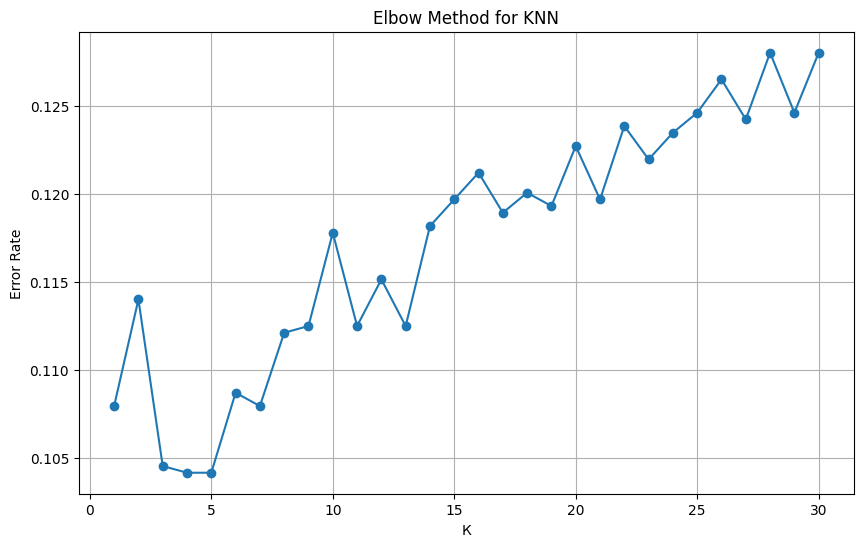

In [ ]:
errors = []

for k in range(1, 31):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_smote, y_train_smote)
    pred = knn_temp.predict(X_test_scaled)
    errors.append(np.mean(pred != y_test))

plt.figure(figsize=(10,6))
plt.plot(range (1,31), errors, marker='o')
plt.title("Elbow Method for KNN")
plt.xlabel("К")
plt.ylabel("Error Rate")
plt.grid(True)
plt.show()